# PyGeoFetch — 01: Getting Started

**PyGeoFetch** is a universal satellite data pipeline: 22+ providers, 17 spectral
indices, SAR processing, and chainable YAML pipelines — in one CLI and Python API.

### What you'll learn
- Install and verify PyGeoFetch
- Run your first search (no credentials needed)
- Download your first scene (RGB bands only)
- Explore results as a pandas DataFrame
- Use `client.status()` to see your setup at a glance

## 1. Installation

In [ ]:
# Install PyGeoFetch
# Uncomment once and run — then restart the kernel

# !pip install PyGeoFetch           # core only (free providers work immediately)
# !pip install "PyGeoFetch[geo]"    # +rasterio, geopandas, shapely
# !pip install "PyGeoFetch[all]"    # everything including dev tools

# Verify
import pygeofetch

print(f"PyGeoFetch {pygeofetch.__version__} imported successfully")

In [ ]:
# Doctor — full installation diagnostic
# Checks Python version, packages, keyring, and live connectivity to free providers
!PyGeoFetch doctor

## 2. Free Providers — No Credentials Needed

In [ ]:
import pandas as pd

from pygeofetch.providers import get_free_providers, list_provider_info

all_providers = list_provider_info()
free_ids      = set(get_free_providers())

rows = []
for p in all_providers:
    rows.append({
        "ID":          p["id"],
        "Free?":       "✓" if p["id"] in free_ids else "—",
        "SAR":         "✓" if p.get("sar") else "—",
        "STAC":        "✓" if p.get("stac") else "—",
        "VHR (<1m)":   "✓" if p.get("sub_meter") else "—",
        "Description": p.get("name", ""),
    })

df = pd.DataFrame(rows)
print(f"Total providers: {len(df)}  |  Free (no login): {df['Free?'].eq('✓').sum()}")
print()
print(df[df["Free?"] == "✓"].to_string(index=False))

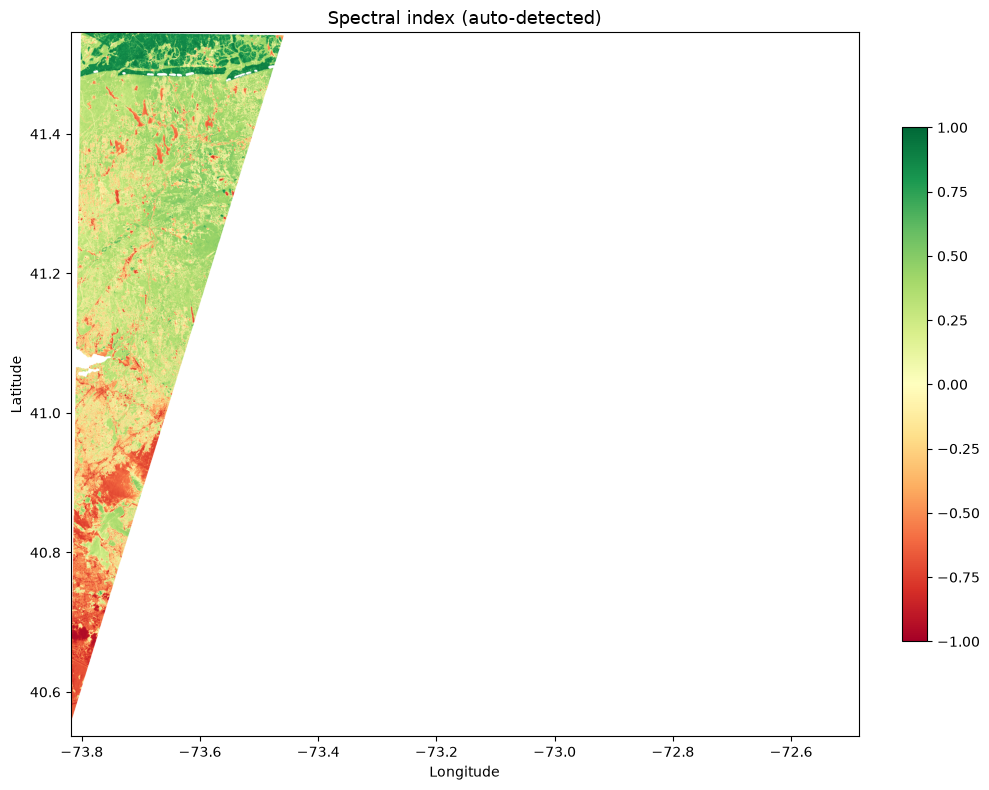

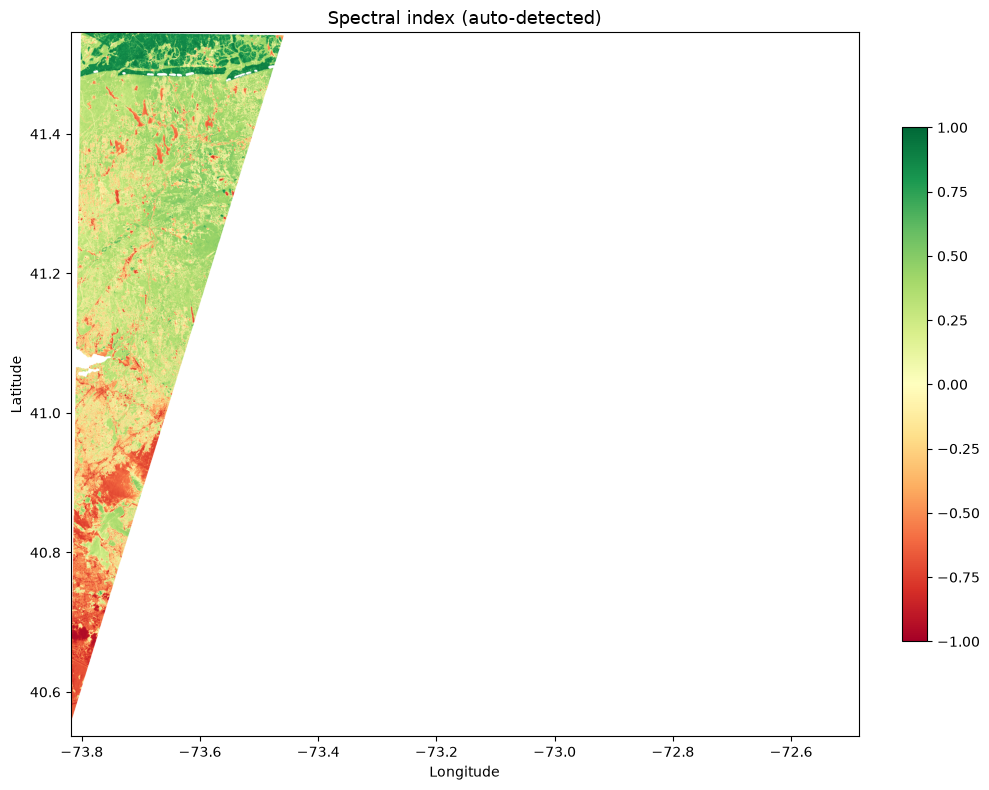

In [1]:
from pathlib import Path

from pygeofetch.viz.plot import Plotter

plotter = Plotter()

data = Path("/home/mrtenkorang/PyGeoFetch-1.0 (2).0-complete/pygeofetch/ndvi/aws_earth/ndvi.tif")

plotter.quicklook(data)

## 3. Your First Search — Python API

In [ ]:
from pathlib import Path

from pygeofetch import PyGeoFetch
from pygeofetch.models.search_query import BoundingBox, SearchQuery

Path("output").mkdir(exist_ok=True)

# Initialise client (WARNING level keeps output clean in notebooks)
client = PyGeoFetch(log_level="INFO")

# NYC bounding box — longitude first
nyc_bbox = BoundingBox.from_string("-74.1,40.6,-73.7,40.9")

query = SearchQuery(
    bbox=nyc_bbox,
    start_date="2024-01-01",
    end_date="2024-06-01",
    cloud_cover_max=15,
    max_results=50,
    sort_by="cloud_cover",
    sort_ascending=True,
)

results = client.search(query, providers=["aws_earth", "planetary_computer"])
print(f"\nFound {len(results)} scenes")

## 4. Explore Results

In [ ]:
import pandas as pd

records = []
for r in results:
    records.append({
        "id":         r.id[:40],
        "provider":   r.provider,
        "satellite":  r.satellite or "—",
        "date":       str(r.datetime)[:10] if r.datetime else "—",
        "cloud_pct":  f"{r.cloud_cover:.1f}" if r.cloud_cover is not None else "—",
        "score":      f"{r.score:.2f}",
        # New SAR/product fields (populated for SAR products)
        "product_type":  r.product_type or "—",
        "polarisation":  r.polarisation or "—",
    })

df = pd.DataFrame(records)
print("Top 10 clearest scenes:")
print(df.head(10).to_string(index=False))

In [ ]:
# Inspect one scene in detail
scene = results[0]
print(f"Scene ID:      {scene.id}")
print(f"Provider:      {scene.provider}")
print(f"Satellite:     {scene.satellite}")
print(f"Date/Time:     {scene.datetime}")
print(f"Cloud cover:   {scene.cloud_cover}%")
print(f"Product type:  {scene.product_type or 'N/A'}")
print(f"Polarisation:  {scene.polarisation or 'N/A'}")
print(f"Pass dir:      {scene.pass_direction or 'N/A'}")
print(f"GSD (m):       {scene.gsd_m or 'N/A'}")
print(f"Score:         {scene.score:.2f}")
print(f"Assets:        {list(scene.assets.keys())[:8]}")

In [ ]:
# Save results to GeoJSON — used in notebook 04 for downloads
client.searcher.save_results(results, Path("output/nyc_results.geojson"))
print(f"✓ Saved {len(results)} results → output/nyc_results.geojson")

## 5. Your First Download

In [ ]:
from pygeofetch.models.download_task import DownloadOptions

best = results[0]
print(f"Downloading: {best.id}")
print(f"Cloud cover: {best.cloud_cover:.1f}%")

options = DownloadOptions(
    parallel=1,
    retry_attempts=3,
    resume=True,
    verify_checksum=False,
    on_failure="skip",
    bands=["B02", "B03", "B04"],   # RGB only — ~150 MB vs ~600 MB full scene
)

dl_results = client.download(
    [best],
    destination=Path("output/downloads/"),
    options=options,
)

for dr in dl_results:
    if dr.success:
        size_mb = dr.bytes_downloaded / 1024 / 1024
        print(f"\n✓ Downloaded {dr.data_id} ({size_mb:.1f} MB)")
    else:
        print(f"\n✗ Failed: {dr.error}")

## 6. System Status

In [ ]:
status = client.status()
print(f"PyGeoFetch v{status['version']}")
print(f"Authenticated providers : {status.get('providers_authenticated') or 'none'}")
print(f"Free providers ready    : {len(status.get('providers_free', []))}")
print(f"Cache entries           : {status.get('cache_entries', 0)}")
print(f"Cache hit rate          : {status.get('cache_hit_rate', 0):.0%}")

---
## Summary
- ✅ Installed and verified PyGeoFetch  
- ✅ Listed 22 providers — 10 need no login  
- ✅ Searched AWS Earth + Planetary Computer (free) — federated, deduplicated  
- ✅ Inspected all fields including new SAR fields (product_type, polarisation, pass_direction)  
- ✅ Downloaded RGB bands only (75% smaller than full scene)  

**Next:** Notebook 02 — Authentication & all 22 providers